# Trabajo Semanal N°2 : 'Modelizando un ADC'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026

En la siguiente tarea semanal se simulara el bloque de cuantizacion de un ADC para muestrear una señal $sr$ conformada por una senoidal $xx$ contaminada por un nivel de ruido declarado como $nn$. Los parametros de resolucion del ADC, como el numero de **B**-bits y el nivel de potencia del ruido $P_{n}$, en el codigo llamado: $pot$ _ $ruido$ _ $analog$, se variaran para analizar como impactan las distintas configuraciones en el  resultado. Por ultimo, se simula el efecto de *aliasing* descripto en el **TS0** para estudiar sus consecuencias en el espectro frecuencial.  


A continuacion se describen las caracteristicas definidas en el codigo para cada pieza de la simulacion: 

**SEÑAL SENOIDAL**: Se aplica la funcion de señal senoidal, definida con $ff=1 Hz$ y $V_{max} = \sqrt{2}$, para cumplir con el Teorema de Nyquist la caracteriztica de energia normalizada, respectivamente.

**SECUENCIA DE RUIDO**:  Definido como Gaussiano con la funcion $np.random.normal$, que se le ingresan valores para la media, la varianza y el tamaño del vector. Se pide que sea de caracter aditivo por lo que se define comotañaño: $N$, para la $\mu = 0$ y como varianza: $\sigma$ se usa la raiz de la potencia del ruido: $P_n = k_n * P_q$, donde $k_n$ es el factor de escala que va a tomar los valores $[1/10, 1, 10]$ y $P_q$ es la potencia del ruido de cuantizacion.

**RUIDO DE CUANTIZACION**: El error introducido al representar una señal continua con un numero finito de niveles, que aparece cuando la señal es muestreada ´por el ADC. En el codigo, se calcula como la resta entre la $Srq$: ADC out, y $Sr$: ADC in. Su potencia: $P_q = \frac{q^2}{12}$, siendo $q$ los pasos de cuantizacion: el ancho de los *escalones* de cuantizaion en los cuales se separan el rango analogico y esta definido por $q = \frac{V_{max}-V_{min}}{2^B}$ la amplitud total del ADC dividida por los $2^{B-bits}$ niveles, que estaran defindos por el valor que tome $B= [4, 8, 16]$. 

**ADC**: Se le declara una frecuencia de muestreo $fs= 1000Hz$ y un rango analogico de $V_f = \pm 2V$. Resulta en un ADC que 'acepta' señales existentes entre -2V y 2V y las discretiza  a $2^B$ niveles separados por $\frac{2*V_f}{2^B}$ Volts.  

A continuacion se muestra el codigo diseñado con todas las caracteristicas detalladas: 

In [39]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
#%%
#----------------------------------- Datos de la simulación---------------------------
fs =  1000 # frecuencia de muestreo (Hz)
N = 1000 # cantidad de muestras
####fs1= fs
ts = 1/fs # tiempo de muestreo
df = fs/N # resolución espectral (=1)
dc = 0
ph = 0

# Datos del ADC
Vf = 2      #Vf max = 2  y Vf min= -2, rango TOTAL=4
B4= 4       #B-bits para a)
B8 = 8
B16 = 16
B10 = 10
B = B4

# Definicion funciónes seno
def func_sen(Vmax=1, dc = dc, ff=1, ph=ph, nn = N, fs=fs):
    N= np.arange(nn)
    tt = N/fs    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc
    return tt, xx

#%%
## DEFINICIONSEÑAL
tt, xx = func_sen(ff = 1, Vmax= np.sqrt(2)) # amp, dc, frec,p, N, fs
xx = xx.flatten()
# Normalizacion
xx=xx/np.std(xx)  
# Calculo de energia, se espera E =1
E = np.mean(xx**2)

# POTENCIA
q = (2*Vf)/(2**B)# paso de cuantización de q Volts = (Vmax - Vmin)/2^B
pot_ruido_cuant = q**2/12 # Watts

k01 = 1/10# escala de la potencia de ruido analógico
k1 = 1
k10 = 10
k = k1

pot_ruido_analog = pot_ruido_cuant * k #potencia del ruido analogico
sigma = np.sqrt(pot_ruido_analog)

## RUIDO
nn=np.random.normal(0, sigma, N) #señal de ruido analogico
# media: 0, desvio: raiz de ruido analogico: ruido cuant * k
sr = xx + nn # señal analógica de entrada al ADC (con ruido analógico)

## RUIDO CUANTIZADO
srq = np.round(sr/q)*q   #ADC OUT
#Ej: si q=0.1 y sr=0,43, hago 0.43/0.1=4.3, redondeo para -> 4, entonces hago4*(q=0.1)=0.4
nq =  srq-sr # señal de ruido de cuantización || aca se hace la diferencia entre la señal y la señal cuantizada (ambas con ruido)

# CALCULO FFT + VECT FRECS
#Uso la fft aplicada sobre señales en el tiempo para verlas en el espectro 
ft_SR =  1/N*np.fft.fft(sr)          #sr: analogica con ruido 
ft_Srq = 1/N*np.fft.fft(srq)         #srq: cuantizada
ft_As =  1/N*np.fft.fft(xx)          #As: senoidal limpia
ft_Nq =  1/N*np.fft.fft(nq)          #Nq: ruido cuantizado= sr-srq
ft_Nn =  1/N*np.fft.fft(nn)          #Nn: ruido analogico 

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)   #vector de frecs desde 0 hasta fs-1  
bfrec = ff <= fs/2    #bfrec: filtro booleano 
Nnq_mean = np.mean(np.abs(ft_Nq)**2)
nNn_mean = np.mean(np.abs(ft_Nn)**2)


El calculo de las transformadas se hace a travez de la funcion de *Fast Fourier Transform* : *fft* y el vector de valores de frecuencias, que ejerce como eje $x$, con un filtro para solo graficar la mitad del espectro. 

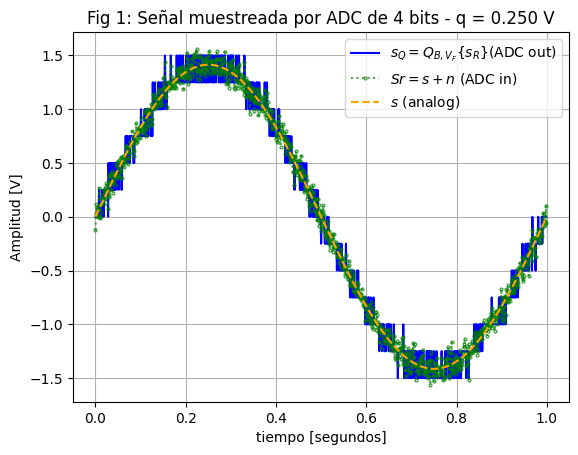

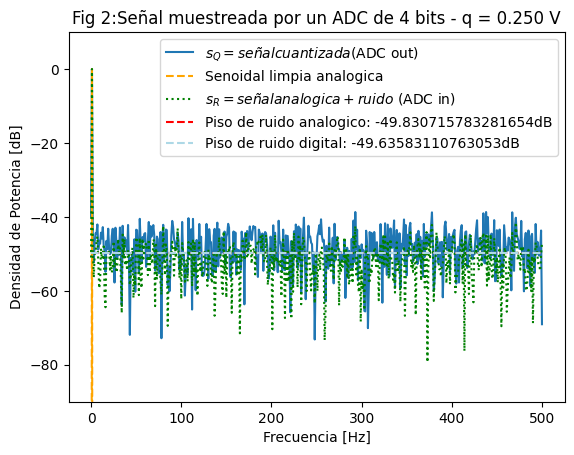

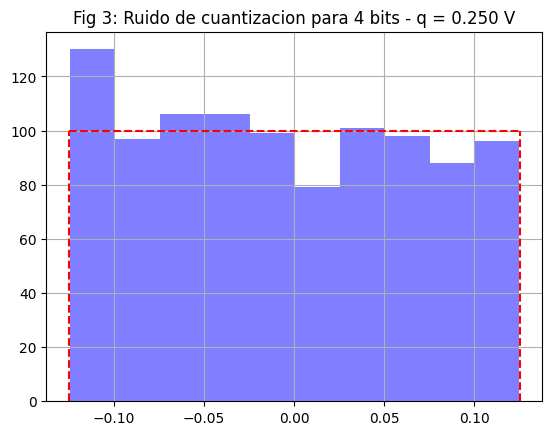

In [40]:
#%%
## GRAFICOS 
# GRAF 1: SEÑAL + RUIDO
plt.figure()
plt.plot(tt, srq, color='blue', label='$s_Q = Q_{B,V_F}\{s_R\} $(ADC out)')
plt.plot(tt, sr, color='g',alpha= 0.7, ls='dotted',marker='o',markerfacecolor='none',markeredgecolor='g',markersize=2, label='$ Sr= s + n $ (ADC in)')
plt.plot(tt, xx, color='orange', ls='--', label='$s$ (analog)')
plt.title('Fig 1: Señal muestreada por ADC de {:d} bits - q = {:3.3f} V'.format(B, q) )
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid(True)
plt.show()
  
## GRAF 2: ESPERCTRO 
piso_ruido_analogico = 10* np.log10(2* nNn_mean)
piso_ruido_digital = 10* np.log10(2* Nnq_mean)
plt.figure()
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), label='$ s_Q =señal cuantizada $(ADC out)' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_As[bfrec])**2), color='orange', ls='--', label='Senoidal limpia analogica' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label='$ s_R = señal analogica + ruido $ (ADC in)' )
plt.hlines(y= piso_ruido_analogico, xmin=0, xmax=500, colors='r', linestyles='--',  label= f'Piso de ruido analogico: {piso_ruido_analogico}dB')
plt.hlines(y= piso_ruido_digital , xmin=0, xmax=500, colors='lightblue', linestyles='--',  label= f'Piso de ruido digital: {piso_ruido_digital}dB')
plt.title('Fig 2:Señal muestreada por un ADC de {:d} bits - q = {:3.3f} V'.format(B4, q) )
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.ylim(-90, 10)
plt.show()

## GRAF 3: HISTOGRAMA 
bins =10
xlim = q/2
ylim = N / bins
plt.figure()
plt.title('Fig 3: Ruido de cuantizacion para {:d} bits - q = {:3.3f} V'.format(B4, q) )
plt.hist(nq, bins=bins, color='blue', alpha=0.5)
plt.hlines(y= ylim, xmin=-xlim, xmax=xlim, colors='r', linestyles='--')
plt.vlines(x=-xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.vlines(x=xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.grid(True)
plt.show()

La Figura 1 presenta la señal senoidal pura, contaminada y digitalizada, en la Fig. 2 vemos el espectro de las mismas señales con el agregado del piso de ruido digital y analogico, calculados como el promedio de la densidad espectral de su potencia y llevandolas a escala de decibelios. La Figura 3, presenta el *Histograma del Ruido de Cuantizacion*, que cuantifica la cantidad de muestras que se posiciona en cada paso de cuantificacion, las lineas punteadas rojas, representan la probabilidad perfectamente uniforme.

A continuacion, se muestran los valores en dB de los pisos de Ruido Digital y Ruido Analogico con las configuraciones de distintos $B$ y $k$, para despues analizar como influyen en los parametros en el espectro.

In [41]:
#%%
# Valores de K y B a comparar
ks = [1/10, 1, 10]
Bs = [4, 8, 16]

# Encabezado de la tabla
print("{:<8} {:<8} {:<20} {:<20}{:<20}".format("Bits", "k", "Piso analógico[dB]", "Piso digital[dB]", "Diferencia"))
print("-"*75)

for B in Bs:
    q = (2*Vf)/(2**B)
    pot_ruido_cuant = q**2/12
    for k in ks:
        # Potencia de ruido analógico
        pot_ruido_analog = pot_ruido_cuant * k
        sigma = np.sqrt(pot_ruido_analog)
        # Señal senoidal normalizada
        tt, xx = func_sen(Vmax=np.sqrt(2))
        xx = xx/np.std(xx)
        # Ruido analógico
        nn = np.random.normal(0, sigma, N)
        sr = xx + nn
        # Cuantización
        srq = np.round(sr/q)*q
        nq = srq - sr
        # FFTs
        ft_Nn = 1/N*np.fft.fft(nn)
        ft_Nq = 1/N*np.fft.fft(nq)
        # Pisos de ruido (promedio espectral)
        piso_analogico = 10*np.log10(2*np.mean(np.abs(ft_Nn)**2))
        piso_digital   = 10*np.log10(2*np.mean(np.abs(ft_Nq)**2))
        dif = piso_digital - piso_analogico
        # Mostrar fila
        print("{:<8} {:<8} {:<20.2f} {:<20.2f} {:<10.2f}".format(B, k, piso_analogico, piso_digital, dif))

Bits     k        Piso analógico[dB]   Piso digital[dB]    Diferencia          
---------------------------------------------------------------------------
4        0.1      -59.95               -49.25               10.70     
4        1        -49.92               -49.68               0.24      
4        10       -39.90               -49.82               -9.91     
8        0.1      -84.29               -73.73               10.56     
8        1        -73.61               -73.88               -0.26     
8        10       -63.92               -73.90               -9.98     
16       0.1      -132.41              -121.71              10.70     
16       1        -122.35              -121.98              0.37      
16       10       -112.27              -122.06              -9.79     


Los valores de $k$ determinan las variaciones del *Ruido Analogico*, cuanto menor sea el valor de $k$, menor sera el piso en dB. Esto ocurre porque la potencia del ruido depende directamente de $k$, dado que $\sigma = P_q *k $ indica cuanto se alejan los valores del valor medio: $\mu$. Entonces, mayor sea $k$ mayor sera $\sigma$ y mayor sera el Ruido Analogico. La potencia del ruido analogico es directamente proporcional a $k$.

El *Ruido Digital* no se ve afectado por $k$, los valores varian en pequeñas unidades. En cambio, varia significativamente para cambios de $B-bits$, la cantidad de bits mejora la calidad del muestreo, por eso el piso de ruido digital se vuelve despreciable con el aumento de $B$. La cantidad de Bits, influye sobre $q$. 

La columna *Diferencia* muestra la resta entre el piso digital y el analogico, la diferencia entre pisos sigue la dinamica aproximada de $[10, 0, -10]dB$ para $k =0.1; 1; 10$, respectivamente lo que reafirma, que mayor sea $k$, mayor sera el ruido analogico, por los que la diferencia da negativa para todos los casos de $k=10$.  

Se proyectan imagenes de algunas configuraciones para mostrar los cambios:

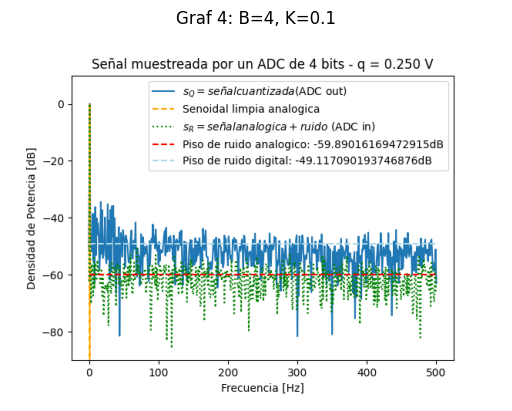

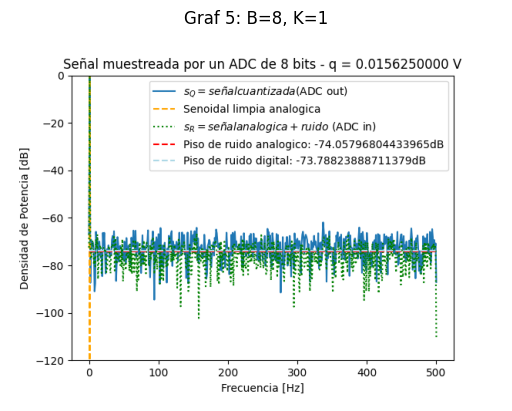

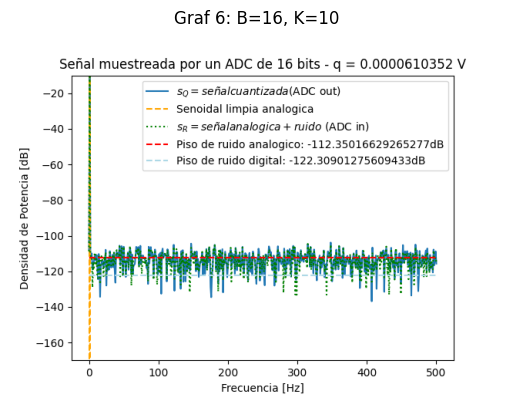

In [42]:
import matplotlib.pyplot as plt
img = plt.imread("../TS 2/espectro B=4, k=0.1.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 4: B=4, K=0.1") 
plt.show()

img = plt.imread("../TS 2/espectro B=8, k=1.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 5: B=8, K=1") 
plt.show()

img = plt.imread("../TS 2/espectro B=16, k=10.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 6: B=16, K=10") 
plt.show()

El Grafico 4, muestra un valor bajo de ruido analogico, por su $k=1/10$, ero la cantidad de bits es baja,dando iuna Potencia de cuantizciondominante. Para el cao del Grafico 5, expone el caso 'intermedio' donde la diferencia entre los pisos de ruido es aproximadamente cero, ambos contribuyen de manera similar. El Grafico 6, que tiene un valor de $k=16$ muestra un piso digital casi invisible frente al analogico, seria un 'caso *ideal*' para el muestreo, ya que presenta alta resolucion digital. 

La relacion entre la cantidad de Bits se ve reflejada cuando se reemplazan los valores del experimento a la ecuacion del $SNR_{[dB]}= 10*log(\frac{P_x}{P_n})$ y resulta en que el calculo del $SNR$ depende de los factores $B$ y $k$ : 

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k * P_q})$

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k }*\frac{12}{q^2})$

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k }*12*(\frac{2^B}{V_f})^2)$

$SNR_{[dB]}= 20*log(\frac{A_x}{V_f}) + 20*log(2^B) + 10*log(\frac{1}{ k }) +10*log(6)$

$SNR_{[dB]}= 20*log(\frac{1}{2}) + 20*B*log(2) + 10*log(\frac{1}{k}) +10*log(6)$

$SNR_{[dB]}= -6.02 + 7.7815 + 6.02*B + 10*log(\frac{1}{k}) $

Se agrega un cuadro que muestra los cambios del SNR $[dB]$ calculadfos con la ecuacion:

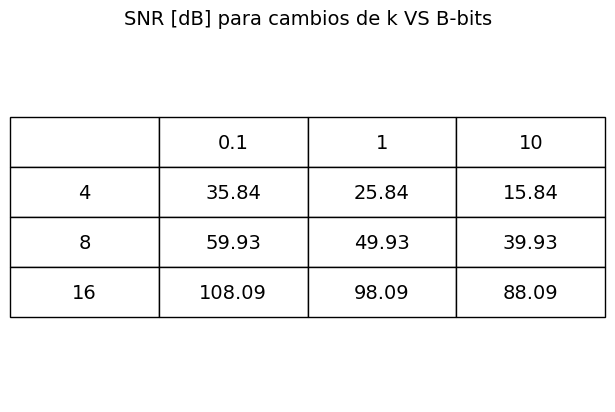

In [43]:
#%%  BONUS: SNR <-> B-BITS 
SNR = [ 
    ['', 1/10, 1, 10],
    [4, 35.84, 25.84, 15.84],
    [8, 59.93, 49.93, 39.93],
    [16, 108.09, 98.09, 88.09]
]
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
tabla = ax.table(cellText=SNR, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(14)
tabla.scale(1.2, 3)
plt.title("SNR [dB] para cambios de k VS B-bits", fontsize=14)
plt.show()

Como se puede observar en la tabla, los cambios para $k$ son exponenciales con factor: $10$ e inversos al aumento de $k$.Dados por el $log(\frac{1}{k})$. Sobre, la cantidad de bits, el aumento es lineal con pendiente $6.02$ y una ordenada: $1.76 + 10*log(\frac{1}{k})$ y la variable independiente: $B$.

Por ultimo se grafica el espectro de 2 senoidales con frecuencias $f_1 = 400Hz$ y $f_2 = 600 Hz$, usando $f_s = 1kHz$, para analizar el *Efecto Aliasing*.

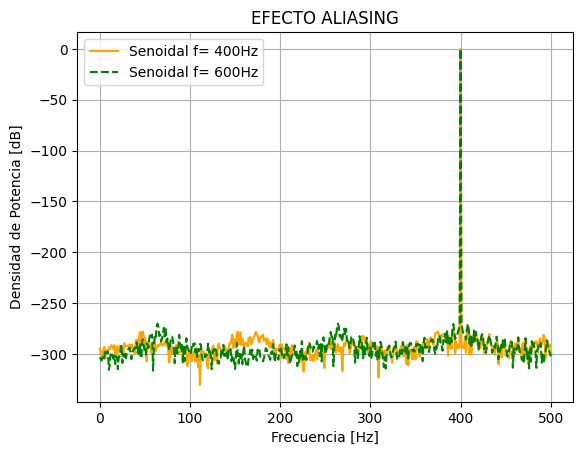

In [44]:
## BONUS
# EFECTO ALIASING 

falias1 = 400
tt1, xx1 = func_sen(ff=falias1, Vmax=np.sqrt(2))
xx1 = xx1.flatten()
xx1 = xx1/np.std(xx1)
E1 = np.mean(xx1**2)

falias2 = 600
tt2, xx2 = func_sen(ff= falias2, Vmax= np.sqrt(2))
xx2 = xx2.flatten()
xx2 =xx2/np.std(xx2)  
E2 = np.mean(xx2**2)

#Uso la fft aplicada sobre señales en el tiempo para verlas en el espectro 
ft_xx1 = 1/N*np.fft.fft(xx1)           
ft_xx2 = 1/N*np.fft.fft(xx2)         

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)    
bfrec = ff <= fs/2    

### GRAFICO
plt.figure()
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_xx1[bfrec])**2), color='orange', label=f'Senoidal f= {falias1}Hz' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_xx2[bfrec])**2), color= 'green', linestyle='--', label=f'Senoidal f= {falias2}Hz')
plt.title('EFECTO ALIASING')
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid(True)
plt.show()

El grafico muestra la energia concentrada en $400Hz$ para **ambas** senoidales, aunque sus frecuencias sean distintas. La razon de este comportamiento se explica mediante el Teorema de Muestreo de Nyquist - Shannon, el cual establece la condicion fundamental para realizar un muestreo correcto: la frecuencia de la señal debe ser mayor o igual a la mitad de la frecuencia de muestreo $ff≤\frac{f_s}{2}$. Si la condicion no se cumple, se produce el fenomeno de Aliasing, que significa que las frecuencias altas se 'disfrazan' de señales de frecuencias mas bajas, provocando una perdida significativa de informacion. Para determinar, de que manera se distorcionan las señales, existe una frecuencia de Alias, que se define como:  $f_{alias} =  |ff - k*fs |$, donde $k$ representa al numero entero, distinto de cero, mas cercano a la division entre $\frac{ff}{f_s}$. 
Aplicando esta ecuacion al caso analizado: 

- $ K_1 = \frac{600Hz}{1000Hz} = 0.6$  $-> K_1 = 1 $, tal que $f_{alias_1} = | 600Hz - 1*1000Hz | = |-400Hz| = 400Hz$.

La simulacion del bloque de cuantizacion del ADC permitio demostrar como los parametros de resolucion $B_bits$ y el factor de escala de ruido $k$, condicionan los pisos de ruido. Se verifico la naturaleza de la dependencia de cada variable con el piso de ruido digital, psio de ruido analogico y $SNR[dB]$. Finalmente, se describio el Teorema de Nyquist-Shannon y comose ven reflejadas las consecuencias de inclumplirlo en el espectro.